# PyTorch Library

The power of deep learning is enabled by libraries such as PyTorch and TensorFlow that simplify 
- Synthetic data generation
- Defining the machine learning model, loss function and optimizer
- Model training loop with gradient descent
- Visualization of loss and results


# Setting Up a Conda Environment with PyTorch and mp-api on Windows

## Why Python 3.11?

PyTorch and many scientific packages do not yet fully support Python 3.12+, which removed `distutils` and broke several C extension builds. Python 3.11 is currently the safest choice for broad compatibility.

## Step 1: Create the Environment

```bash
conda create -n ml python=3.11 -y
conda activate ml
```

## Step 2: Install PyTorch

Install PyTorch **first**, from the `pytorch` channel, before adding conda-forge packages. This avoids solver conflicts.

**With GPU (NVIDIA CUDA):**

```bash
conda install pytorch torchvision torchaudio pytorch-cuda=12.4 -c pytorch -c nvidia
```

> Check your CUDA version with `nvidia-smi` and adjust `pytorch-cuda=12.4` accordingly.

**CPU only:**

```bash
conda install pytorch torchvision torchaudio cpuonly -c pytorch
```

## Step 3: Install pymatgen and mp-api from conda-forge

```bash
conda install -c conda-forge mp-api pymatgen
```

## Step 4: Install Common ML and Scientific Packages

```bash
conda install -c conda-forge scikit-learn pandas matplotlib seaborn jupyter
```

## Step 5: Optional Extras

```bash
pip install e3nn            # equivariant neural networks
pip install torch-geometric  # PyTorch Geometric for graph NNs
pip install wandb            # experiment tracking
pip install ase              # Atomic Simulation Environment
```

## Sanity Check

```python
python -c "import torch; print(torch.__version__, torch.cuda.is_available())"
python -c "from mp_api.client import MPRester; print('mp-api OK')"
```

## Troubleshooting: Channel Conflicts

If the conda solver struggles with mixed `pytorch` and `conda-forge` channels, enforce strict channel priority:

```bash
conda config --env --set channel_priority strict
```

This prevents conda from cross-substituting packages across channels.

In [1]:
# Linear Regression with PyTorch
# Description: Introductory example for training a linear regression model using PyTorch
# !pip3 install torch
# or run in terminal: conda install pytorch -c pytorch
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Set seed for reproducibility
torch.manual_seed(42)

## 1. Generate synthetic linear data

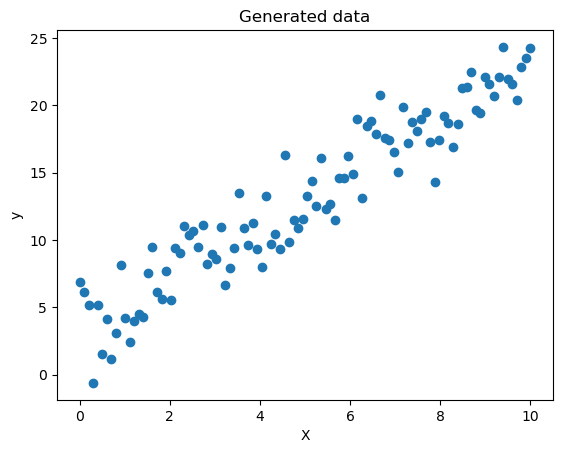

In [2]:
# Generate PyTorch array with data of y = 2*x + 3 + noise
X = torch.unsqueeze(torch.linspace(0, 10, 100), dim=1)  # shape: (100, 1)
y = 2 * X + 3 + torch.randn(X.size()) * 2

plt.scatter(X.numpy(), y.numpy())
plt.title("Generated data")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

## 2. Initialize parameters manually

In [3]:
# Initialize weights and bias, note that we set requires_grad=True to track gradients
w = torch.randn(1, requires_grad=True)  # weight
b = torch.randn(1, requires_grad=True)  # bias

## 3. Define learning rate

In [4]:
# Set learning rate and initialize loss history
lr = 0.01
loss_history = []

## 4. Training loop

In [5]:
# Loop over epochs, compute MSE loss function, use backpropagation of the loss function to calculate gradient, and optimize parameters using gradient descent
# 4. Training loop
epochs = 200
for epoch in range(epochs):
    # Forward pass: compute predicted y
    y_pred = X * w + b

    # Compute Mean Squared Error loss
    loss = ((y_pred - y) ** 2).mean()
    loss_history.append(loss.item())

    # Backward pass
    loss.backward()

    # Update parameters using gradient descent
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    # Zero gradients after update
    w.grad.zero_()
    b.grad.zero_()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 332.4791
Epoch 20, Loss: 6.1037
Epoch 40, Loss: 5.6972
Epoch 60, Loss: 5.3641
Epoch 80, Loss: 5.0911
Epoch 100, Loss: 4.8674
Epoch 120, Loss: 4.6840
Epoch 140, Loss: 4.5338
Epoch 160, Loss: 4.4107
Epoch 180, Loss: 4.3098


## 5. Visualization of loss and results

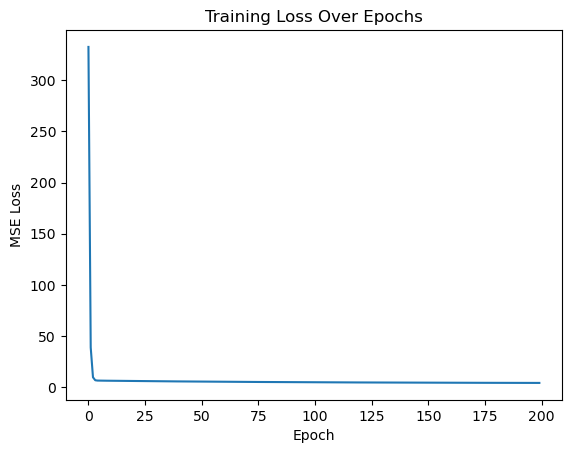

In [6]:
# Plot the loss curve
plt.plot(loss_history)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

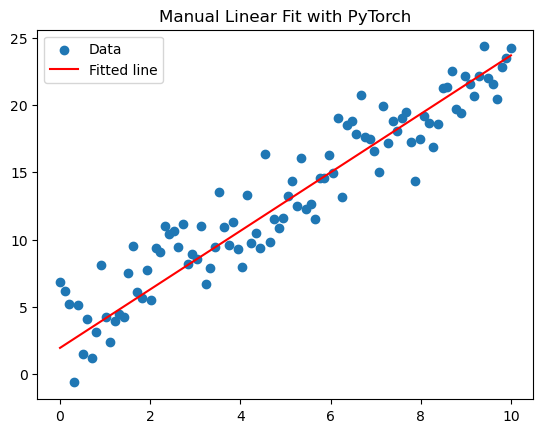

In [7]:

# Plot fitted line
predicted = (X * w + b).detach().numpy()
plt.scatter(X.numpy(), y.numpy(), label='Data')
plt.plot(X.numpy(), predicted, color='red', label='Fitted line')
plt.title("Manual Linear Fit with PyTorch")
plt.legend()
plt.show()

In [8]:

# View learned parameters
print("Learned weight:", w.item())
print("Learned bias:", b.item())

Learned weight: 2.1710855960845947
Learned bias: 1.9622308015823364


> ### Assignment
> 1. Change the learning rate (decrease and increase by about an order of magnitude) and observe how it affects the convergence of the model.
> 2. Increase the number of epochs and observe the effect on the loss curve.
